# Draw Protomodel

Draw a given protomodel. Also has code for plotting respective likelihoods

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Palatino'
plt.rcParams['font.weight'] = '700'
plt.rcParams['axes.labelweight'] = '700'

plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "axes.linewidth": 1.4,
})

In [107]:
# import required protomodel and smodels
from builder.protomodel import ProtoModel
from builder.manipulator import Manipulator
from walker.randomWalker import RandomWalker
from tester.predictor import Predictor
from tester.combiner import Combiner
from tester.critic import Critic
from smodels.matching.theoryPrediction import TheoryPredictionsCombiner


In [129]:
# Insert protomodel
pm = {       
        "masses": {
            1000022: 89.88887,
            1000023: 126.046269,
            1000024: 155.494055,
            1000025: 451.88620440330646
        },      
        "ssmultipliers": {
            (1000022, 1000023): 0.7187750289693996,
            (1000022, 1000024): 0.8752012218056557,
            (1000023, 1000024): 13.297393823368497,
            #(1000023, 1000024): 3.94,
            (1000023, 1000023): 0.3827829221910483,
            (1000023, 1000025): 0.8905272025934413,
            (1000025, 1000025): 0.24574894913009562,
            (1000024, 1000025): 0.6652675985719765
        },
        "decays": {
            1000022: {},
            1000023: { 
                (1000022, 12, 12): 1.0 
            },
            1000024: { 
                (1000022, 2, 1): 1.0
            },
            1000025: { 
                (1000023, 25): 1.0
            }
        }
}

In [133]:
pm = {
    "masses": {
        1000022: 89.88887,
        1000023: 126.046269,
        1000024: 155.494055,
        1000025: 450.009096
    },
    "ssmultipliers": {
        (1000022, 1000023): 0.541516,
        (1000022, 1000024): 1.173898,
        (1000023, 1000024): 12.463147,
        (1000023, 1000023): 0.358768,
        (1000023, 1000025): 13.053994,
        (1000025, 1000025): 0.350866,
        (1000024, 1000025): 0.364985
    },
    "decays": {
        1000022: {},
        1000023: {
            (1000022, 12, 12): 1.0
        },
        1000024: {
            (1000022, 2, 1): 1.0
        },
        1000025: {
            (1000023, 25): 1.0
        }
    }
}

In [134]:
#create manipulator and protomodel object
from base.runEnviron import RunEnviron
RunEnviron.create()
environ = RunEnviron()
ma = Manipulator(pm, environ=environ)
proto = ma.M
proto.createSLHAFile()

[manipulator:0] initializing from dictionary: X1Z, X2Z, X1W, X3Z


'/tmp/.cur0_xcy6ry6y.slha'

In [135]:
#get best combination of results (no need to run random walker if muhat already at 1)

#initalise rvars for randomwalker
rvars = { "walkerid": 0, "jmin": 0, "continueFrom": "",
                 "cheatcode": "no_cheat", "maxsteps": 1000, 
                 "cap_ssm": 100.,
                 "test_param_space": False, "seed": None, "expected": False,
                 "record_history": False, "catch_exceptions": True,
                 "stopTeleportationAfter": -1,
                 "run_mcmc": False }

ma = Manipulator(proto, environ=environ)
rw = RandomWalker(environ=environ, rvars=rvars)
pr = Predictor(0, environ=environ)
co = Combiner()
rw.predict(manipulator=ma)
best_comb = TheoryPredictionsCombiner(proto.bestCombo)

False
[randomWalker:0] Ramping up with slurm jobid unknown
[randomWalker:0] It is Mon Dec 15 18:01:35 2025
[randomWalker:0] template /Users/sahananarasimha/protomodels/builder/templates/template_default.slha allowN1N1 True susy_mode False
ProtoModel (X1Z): K = None, TL = 0.0


In [136]:
#get critic predicitons (if required)
print(rw.critic.predict_critic(proto, keep_predictions=True))
print(proto.K, proto.TL)

{1000022: 89.88887, 1000023: 126.046269, 1000024: 155.494055, 1000025: 450.009096} {(1000022, 1000023): 0.541516, (1000022, 1000024): 1.173898, (1000023, 1000024): 12.463147, (1000023, 1000023): 0.358768, (1000023, 1000025): 13.053994, (1000025, 1000025): 0.350866, (1000024, 1000025): 0.364985}
(True, 'passed both critics')
28.391037178448673 33.691037178448674


In [137]:
#Get best combination object
pr = Predictor(0, environ=environ)
pr.predict(ma)
best_comb = TheoryPredictionsCombiner(proto.bestCombo)

CMS-EXO-20-004, log_llhd 0.0
ATLAS-EXOT-2018-06, log_llhd 0.0
CMS-SUS-20-004, log_llhd 0.0


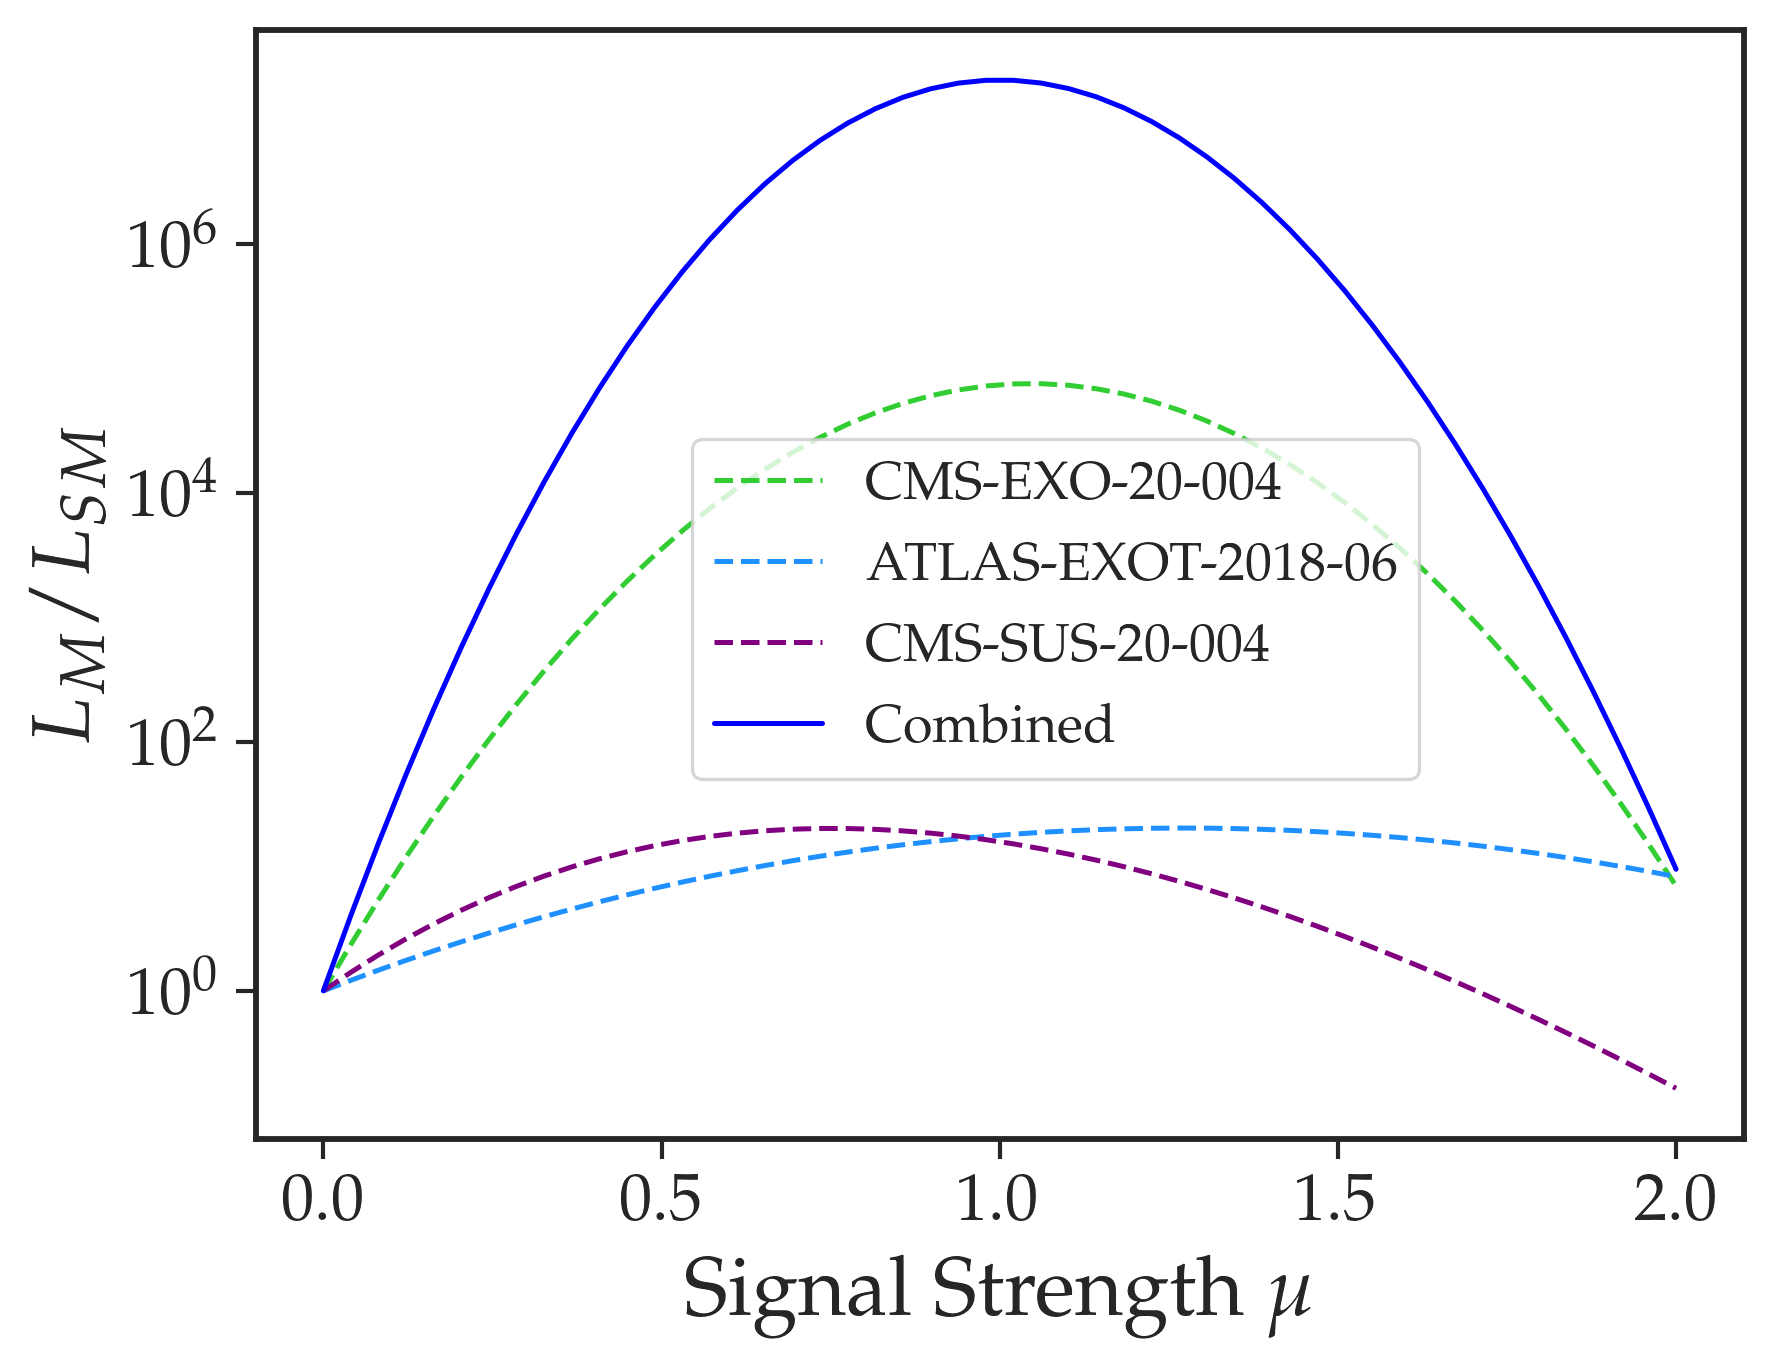

In [147]:
#Plot combined and individual likelihoods
muvals = np.linspace(0.0, 2.0, 50)
fig, ax = plt.subplots()
colors = ['limegreen','dodgerblue','purple']

for i,pred in enumerate(proto.bestCombo):
    pred_llhd = [pred.likelihood(mu)/pred.likelihood(mu=0) for mu in muvals]
    plt.plot(muvals, pred_llhd, '--', label=f'{pred.analysisId()}', color=colors[i])

best_comb_llhd = [ best_comb.likelihood(mu)/best_comb.likelihood(mu=0)  for mu in muvals]

plt.plot(muvals, best_comb_llhd, '-', color='blue', label='Combined')
plt.xlabel(r'Signal Strength $\mu$')
plt.ylabel(r'$L_{M}/L_{SM}$')
plt.yscale('log')
plt.legend(fontsize=13, bbox_to_anchor=(0.8,0.3))
plt.show()

In [149]:
model = pm

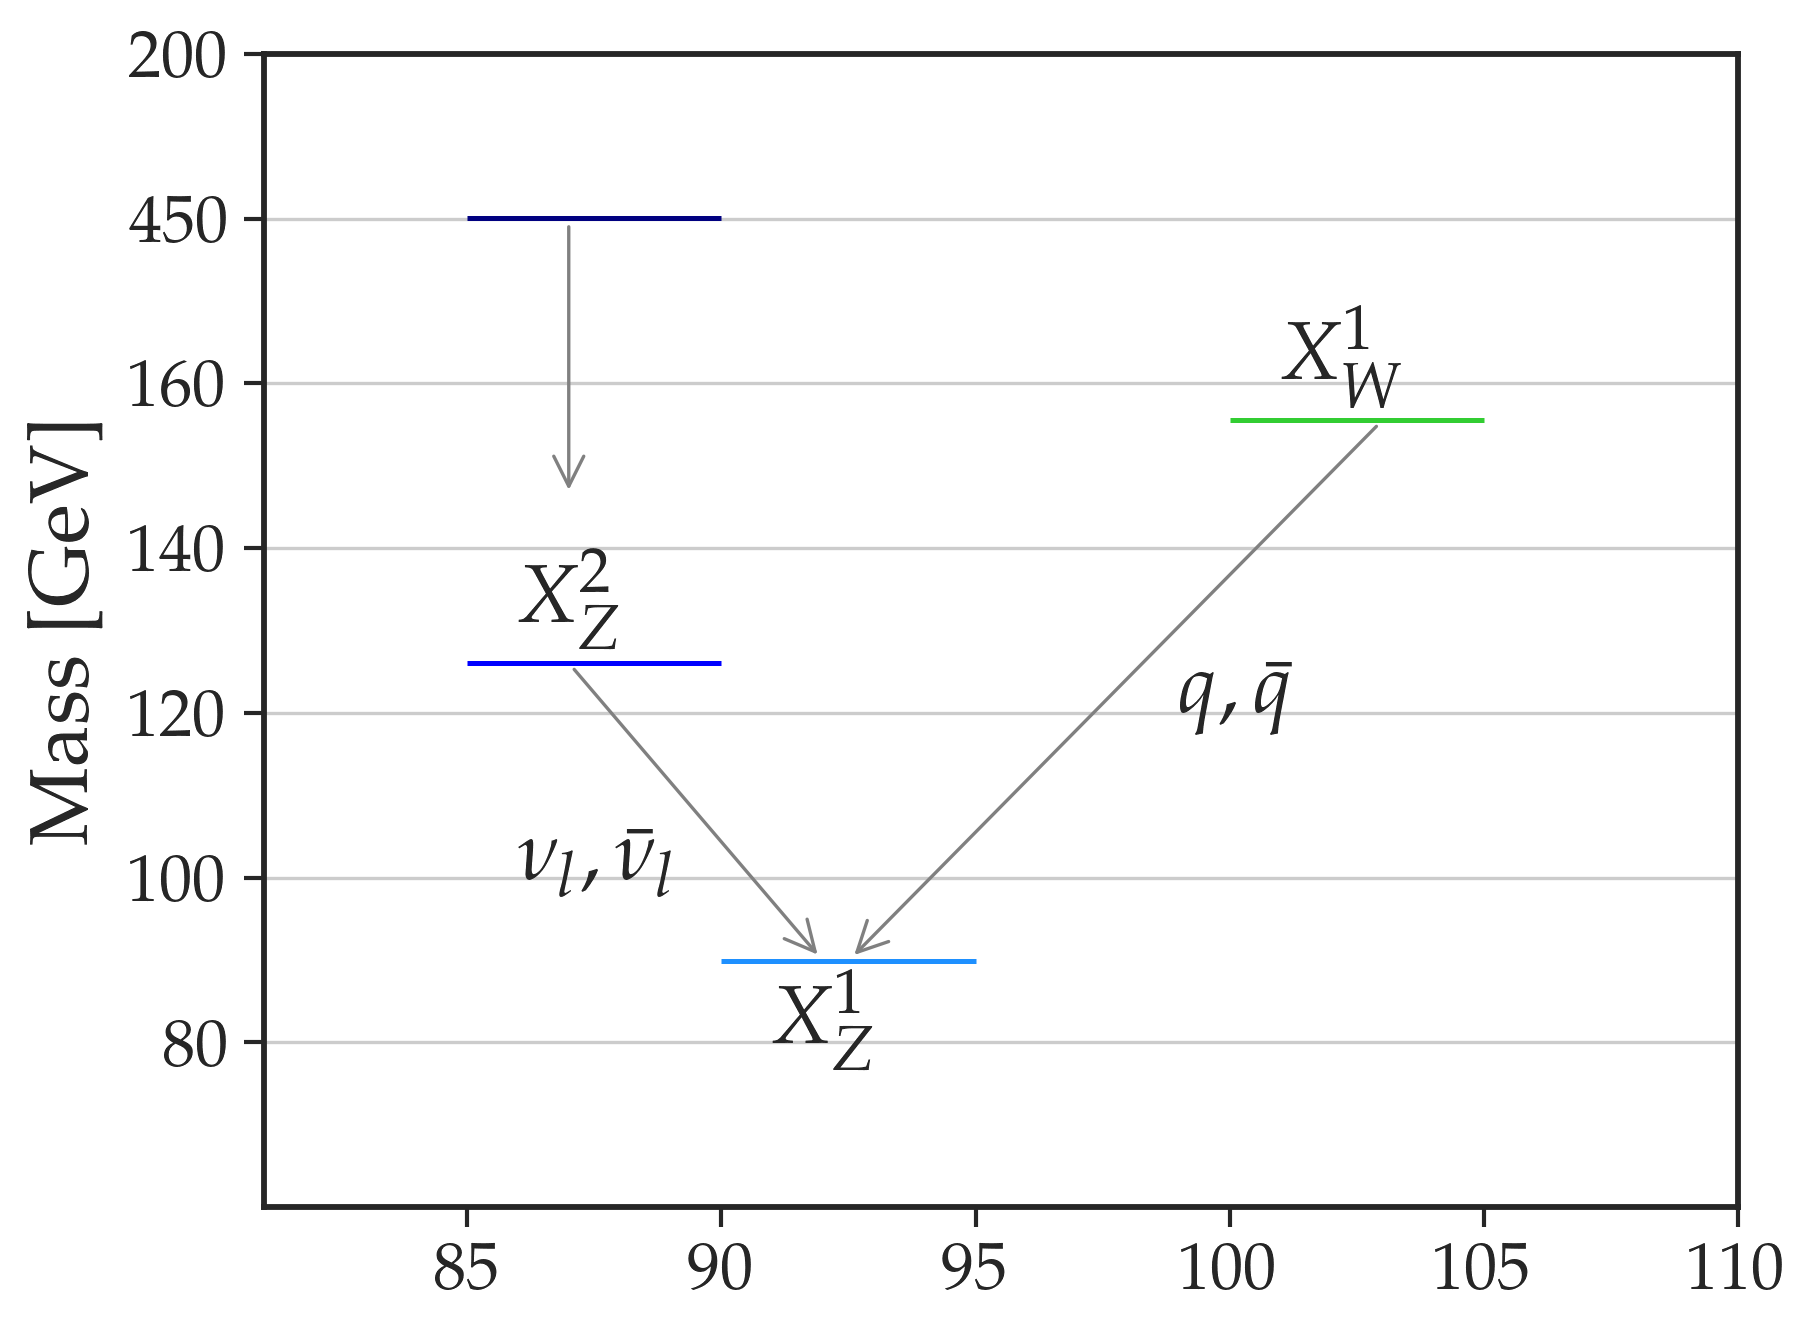

In [158]:
# draw protomodel
fig, ax = plt.subplots()
#proto_dict = {'masses': {1000022: 46.514732, 1000023: 449.803627, 1000024: 131.803097}}
ax.hlines(model['masses'][1000022], 90,95, color='dodgerblue')
ax.hlines(model['masses'][1000023], 85,90, color='blue')
ax.hlines(model['masses'][1000024], 100,105, color='limegreen')
y_fake = model['masses'][1000025] - 270   # plotted position
y_true = model['masses'][1000025]         # true mass

ax.hlines(y_fake, 85,90, color='navy')


plt.annotate('', (92, model['masses'][1000022]), xytext=(87,model['masses'][1000023]),arrowprops=dict(color='gray', arrowstyle='->'), ha='center')
plt.annotate('', (92.5, model['masses'][1000022]), xytext=(103,model['masses'][1000024]),arrowprops=dict(color='gray', arrowstyle='->'), ha='center')
plt.annotate('', (87, model['masses'][1000023]+20), xytext=(87,y_fake),arrowprops=dict(color='gray', arrowstyle='->'), ha='center')

plt.text(86, model['masses'][1000022]+10, r"$\nu_l,\bar{\nu}_l$", fontsize=20)
plt.text(99, model['masses'][1000022]+30, r"$q,\bar{q}$", fontsize=20)

plt.text(86, model['masses'][1000023]+5, r'$X_{Z}^{2}$', fontsize=20)
plt.text(101, model['masses'][1000024]+5, r'$X_{W}^{1}$', fontsize=20)
plt.text(91, model['masses'][1000022]-10, r'$X_{Z}^{1}$', fontsize=20)


#ax.get_xaxis().set_visible(False)
'''
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
'''
ticks = ax.get_yticks().tolist()

# Replace the tick closest to the fake value with the true label
new_labels = []
for t in ticks:
    if abs(t - y_fake) < 5:
        new_labels.append(f"{int(y_true)}")
    else:
        new_labels.append(f"{int(t)}")

ax.set_yticks(ticks)
ax.set_yticklabels(new_labels)

ax.yaxis.grid()
ax.set_xlabel('')
ax.set_ylabel('Mass [GeV]')
ax.set_ylim(60,200)
ax.set_xlim(81,110)
plt.tight_layout()
plt.show()

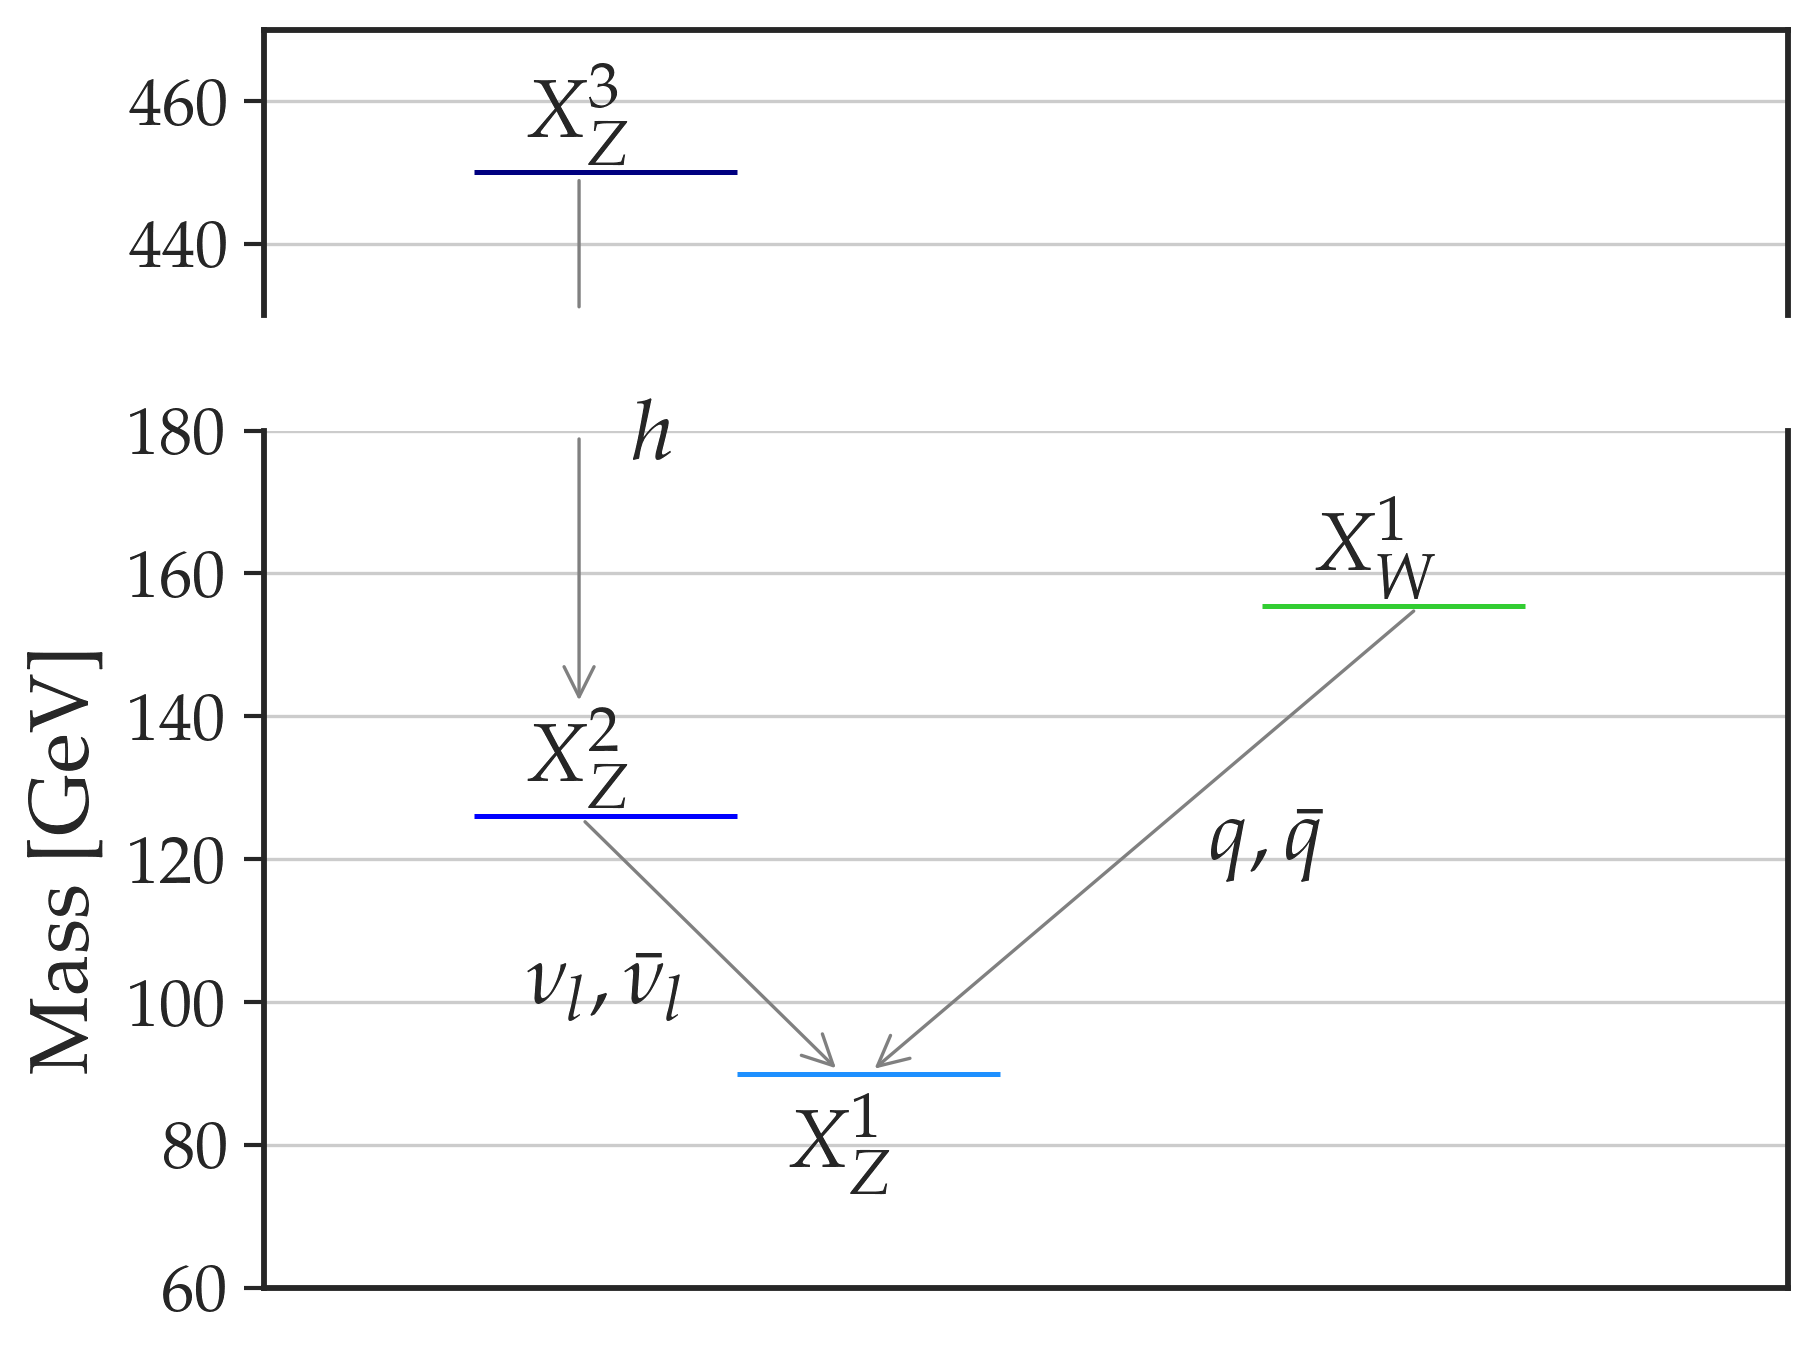

In [178]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True,
    gridspec_kw={'height_ratios': [1, 3]}
)

# Upper axis (true 450 GeV region)
ax1.set_ylim(430, 470)
ax1.hlines(model['masses'][1000025], 85, 90, color='navy')
ax1.annotate('', (87, 430), xytext=(87,model['masses'][1000025]),arrowprops=dict(color='gray', arrowstyle='-'), ha='center')
ax1.text(86, model['masses'][1000025]+5, r'$X_{Z}^{3}$', fontsize=20)


ax2.set_ylim(60, 180)
ax2.hlines(model['masses'][1000022], 90,95, color='dodgerblue')
ax2.hlines(model['masses'][1000023], 85,90, color='blue')
ax2.hlines(model['masses'][1000024], 100,105, color='limegreen')


ax1.spines.bottom.set_visible(False)
ax1.get_xaxis().set_visible(False)
ax2.get_xaxis().set_visible(False)
ax2.spines.top.set_visible(False)

plt.annotate('', (92, model['masses'][1000022]), xytext=(87,model['masses'][1000023]),arrowprops=dict(color='gray', arrowstyle='->'), ha='center')
plt.annotate('', (92.5, model['masses'][1000022]), xytext=(103,model['masses'][1000024]),arrowprops=dict(color='gray', arrowstyle='->'), ha='center')
plt.annotate('', (87, model['masses'][1000023]+15), xytext=(87,180),arrowprops=dict(color='gray', arrowstyle='->'), ha='center')

plt.text(86, model['masses'][1000022]+10, r"$\nu_l,\bar{\nu}_l$", fontsize=20)
plt.text(99, model['masses'][1000022]+30, r"$q,\bar{q}$", fontsize=20)
plt.text(88, model['masses'][1000023]+50, r"$h$", fontsize=20)

plt.text(86, model['masses'][1000023]+5, r'$X_{Z}^{2}$', fontsize=20)
plt.text(101, model['masses'][1000024]+5, r'$X_{W}^{1}$', fontsize=20)
plt.text(91, model['masses'][1000022]-13, r'$X_{Z}^{1}$', fontsize=20)

ax1.yaxis.grid()
ax2.yaxis.grid()
ax2.set_xlabel('')
plt.ylabel('Mass [GeV]')
#ax.set_ylim(60,200)
ax1.set_xlim(81,110)
plt.tight_layout()
plt.show()